In [15]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

# Load the dataset
df_tradingg = pd.read_csv('/content/tradingg.csv')

print('Initial Info:')
display(df_tradingg.info())

# Identify column types
numeric_cols = df_tradingg.select_dtypes(include=[np.number]).columns
categoric_cols = df_tradingg.select_dtypes(include=['object']).columns

# Check for missing values
print('\nMissing values per column:')
display(df_tradingg.isnull().sum())

# Impute missing numerical values with the mean
if not numeric_cols.empty:
    num_imputer = SimpleImputer(strategy='mean')
    df_tradingg[numeric_cols] = num_imputer.fit_transform(df_tradingg[numeric_cols])

# Impute missing categorical values with the most frequent value
if not categoric_cols.empty:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    df_tradingg[categoric_cols] = cat_imputer.fit_transform(df_tradingg[categoric_cols])

print('\nData cleaning complete. No missing values remain:')
display(df_tradingg.isnull().sum())
display(df_tradingg.head())

Initial Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  29 non-null     int64  
 1   datadate    29 non-null     int64  
 2   tic         29 non-null     object 
 3   adjcp       29 non-null     float64
 4   open        29 non-null     float64
 5   high        29 non-null     float64
 6   low         29 non-null     float64
 7   volume      29 non-null     int64  
 8   macd        29 non-null     int64  
 9   rsi         29 non-null     int64  
 10  cci         29 non-null     float64
 11  adx         29 non-null     int64  
 12  turbulence  29 non-null     int64  
dtypes: float64(5), int64(7), object(1)
memory usage: 3.1+ KB


None


Missing values per column:


,0
Unnamed: 0,0
datadate,0
tic,0
adjcp,0
open,0
high,0
low,0
volume,0
macd,0
rsi,0



Data cleaning complete. No missing values remain:


,0
Unnamed: 0,0
datadate,0
tic,0
adjcp,0
open,0
high,0
low,0
volume,0
macd,0
rsi,0


,Unnamed: 0,datadate,tic,adjcp,open,high,low,volume,macd,rsi,cci,adx,turbulence
0,0.0,20090102.0,AAPL,12.964286,12.268571,13.005714,12.165714,26641980.0,0.0,100.0,66.666667,100.0,0.0
1,1.0,20090102.0,AXP,19.330000,18.570000,19.520000,18.400000,10955620.0,0.0,100.0,66.666667,100.0,0.0
2,2.0,20090102.0,BA,45.250000,42.800000,45.560000,42.780000,7010171.0,0.0,100.0,66.666667,100.0,0.0
3,3.0,20090102.0,CAT,46.910000,44.910000,46.980000,44.710000,7116726.0,0.0,0.0,66.666667,100.0,0.0
4,4.0,20090102.0,CSCO,16.960000,16.410000,17.000000,16.250000,40977480.0,0.0,100.0,66.666667,100.0,0.0


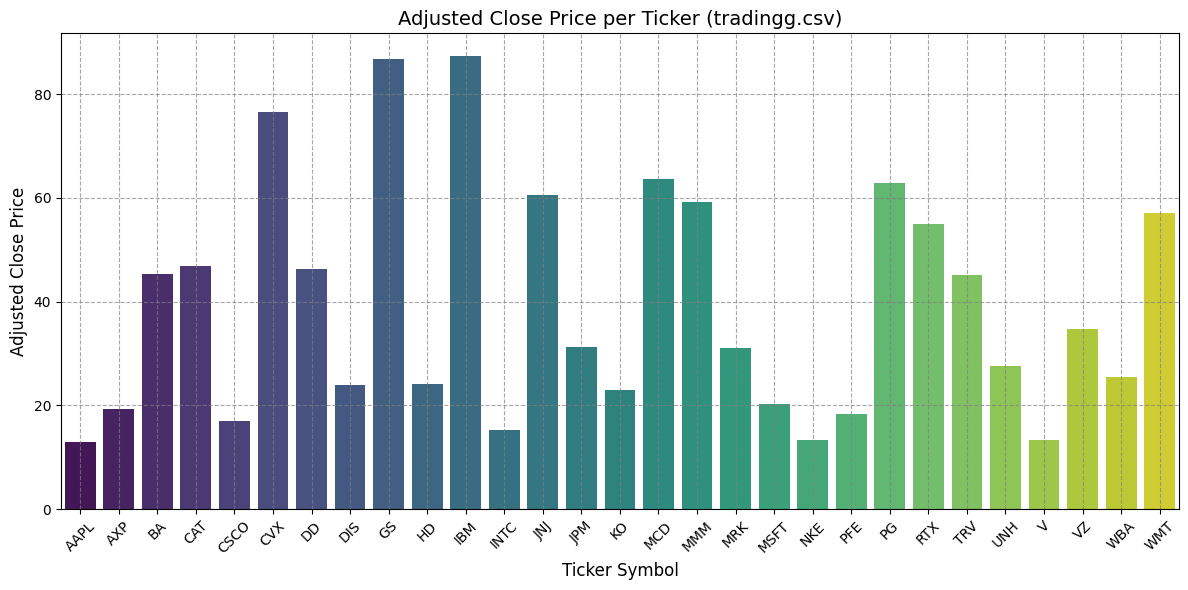

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar chart for ticker vs adjusted close price
plt.figure(figsize=(12, 6))
sns.barplot(x='tic', y='adjcp', data=df_tradingg, palette='viridis', hue='tic', legend=False)

plt.title('Adjusted Close Price per Ticker (tradingg.csv)', fontsize=14)
plt.xlabel('Ticker Symbol', fontsize=12)
plt.ylabel('Adjusted Close Price', fontsize=12)

# Implement the 'true grid' (prominent grid lines)
plt.grid(True, which='both', linestyle='--', linewidth=0.8, color='gray', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

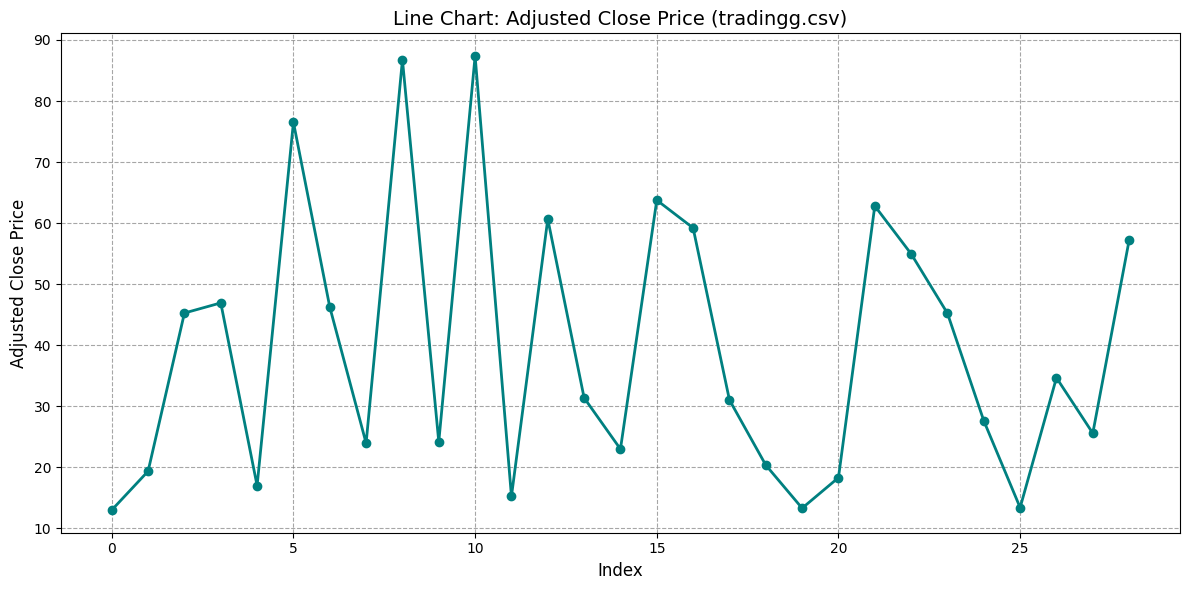

In [17]:
import matplotlib.pyplot as plt

# Create a line chart for Adjusted Close Price
plt.figure(figsize=(12, 6))
plt.plot(df_tradingg.index, df_tradingg['adjcp'], marker='o', linestyle='-', color='teal', linewidth=2)

plt.title('Line Chart: Adjusted Close Price (tradingg.csv)', fontsize=14)
plt.xlabel('Index', fontsize=12)
plt.ylabel('Adjusted Close Price', fontsize=12)

# Implement the 'true grid' (prominent grid lines)
plt.grid(True, which='both', linestyle='--', linewidth=0.8, color='gray', alpha=0.7)

plt.tight_layout()
plt.show()

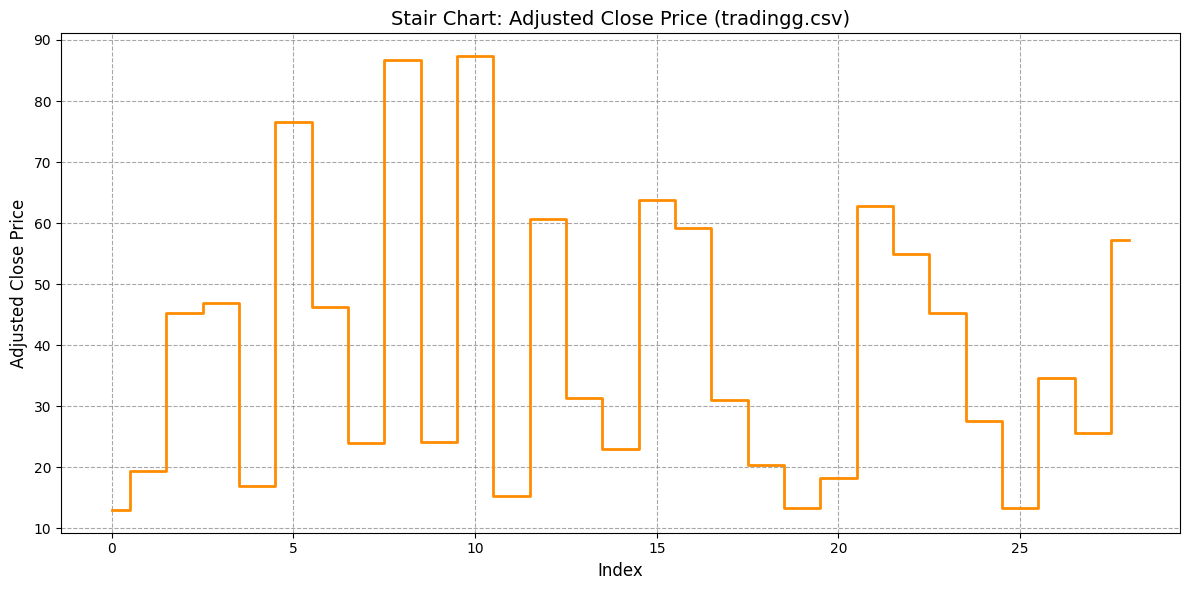

In [19]:
import matplotlib.pyplot as plt

# Create a stair chart for Adjusted Close Price
plt.figure(figsize=(12, 6))
plt.step(df_tradingg.index, df_tradingg['adjcp'], where='mid', color='darkorange', linewidth=2)

plt.title('Stair Chart: Adjusted Close Price (tradingg.csv)', fontsize=14)
plt.xlabel('Index', fontsize=12)
plt.ylabel('Adjusted Close Price', fontsize=12)

# Implement the 'true grid' (prominent grid lines)
plt.grid(True, which='both', linestyle='--', linewidth=0.8, color='gray', alpha=0.7)

plt.tight_layout()
plt.show()

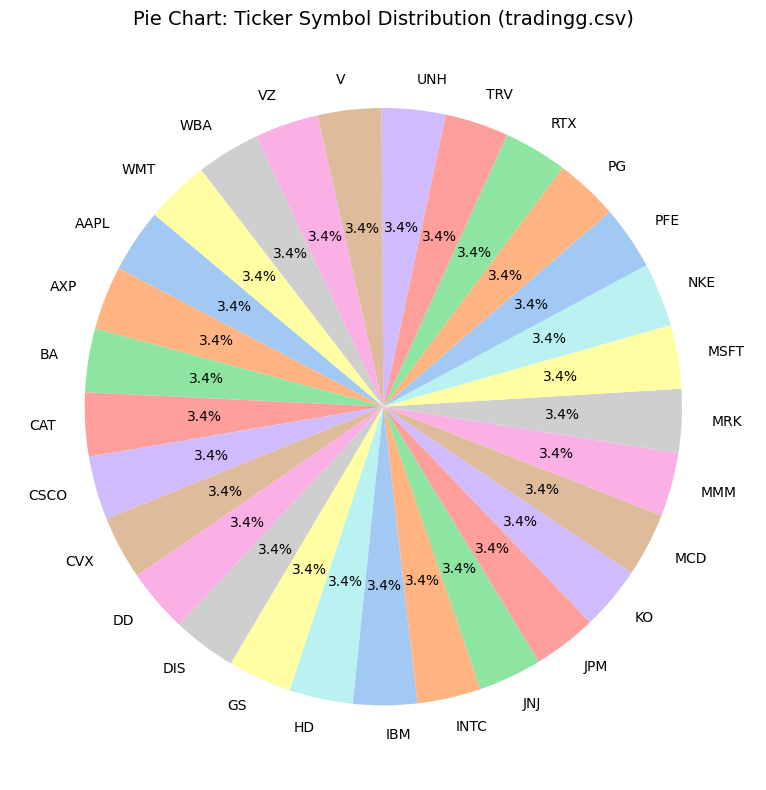

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate counts for the pie chart
tic_counts = df_tradingg['tic'].value_counts()

plt.figure(figsize=(10, 8))
plt.pie(tic_counts, labels=tic_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))

plt.title('Pie Chart: Ticker Symbol Distribution (tradingg.csv)', fontsize=14)

# Apply the 'true grid' to the axis background as requested
plt.gca().set_axis_on()
plt.grid(True, which='both', linestyle='--', linewidth=0.8, color='gray', alpha=0.7)

plt.tight_layout()
plt.show()

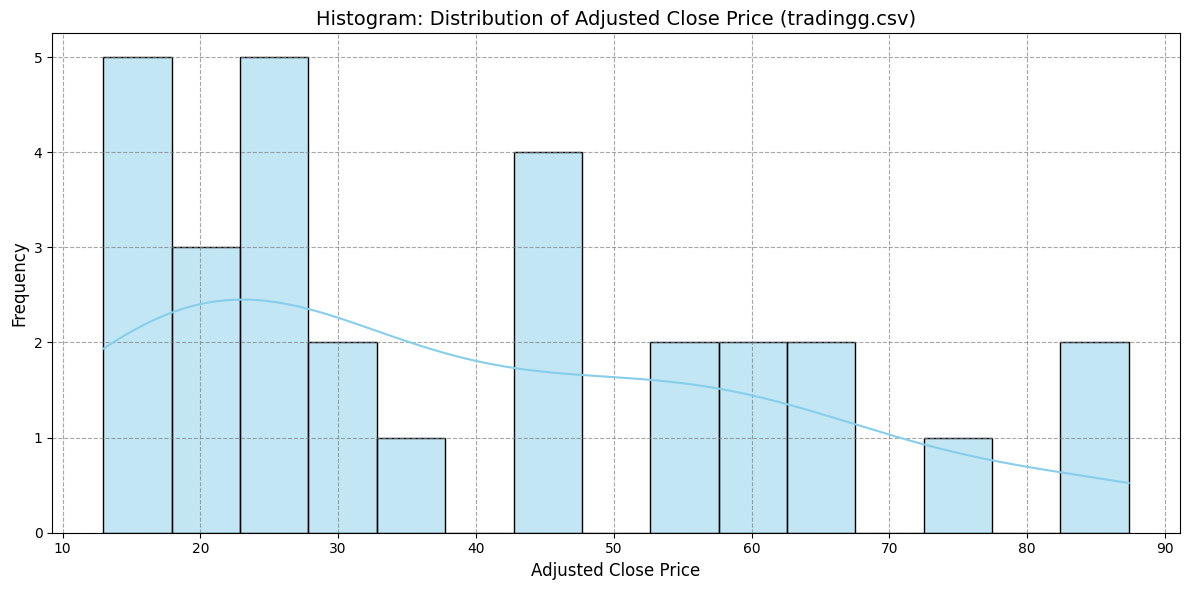

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a histogram for Adjusted Close Price
plt.figure(figsize=(12, 6))
sns.histplot(df_tradingg['adjcp'], bins=15, kde=True, color='skyblue', edgecolor='black')

plt.title('Histogram: Distribution of Adjusted Close Price (tradingg.csv)', fontsize=14)
plt.xlabel('Adjusted Close Price', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Implement the 'true grid' (prominent grid lines)
plt.grid(True, which='both', linestyle='--', linewidth=0.8, color='gray', alpha=0.7)

plt.tight_layout()
plt.show()

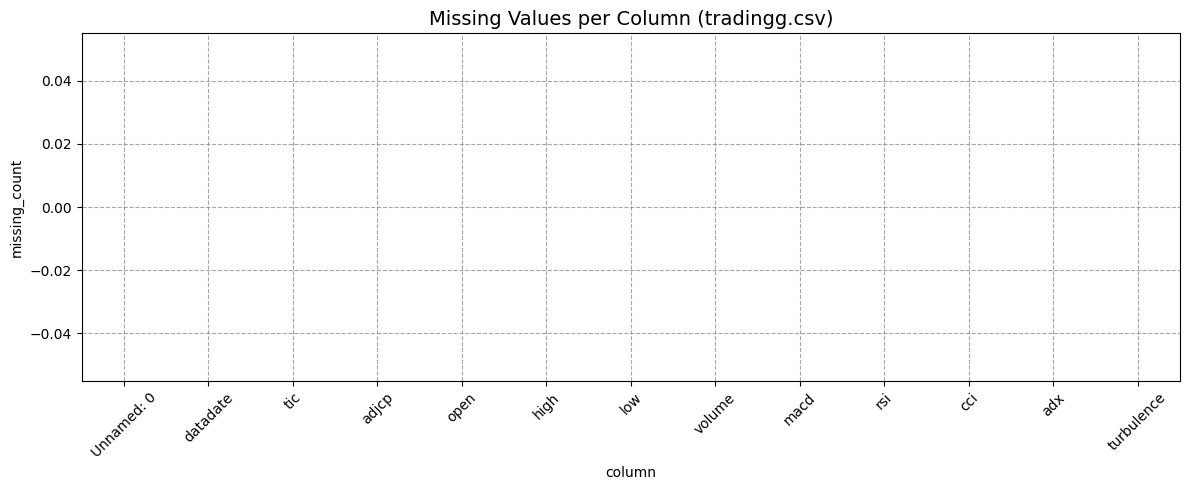

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Missing Variables Chart
missing_values = df_tradingg.isnull().sum().reset_index()
missing_values.columns = ['column', 'missing_count']

plt.figure(figsize=(12, 5))
sns.barplot(x='column', y='missing_count', data=missing_values, palette='mako', hue='column', legend=False)
plt.title('Missing Values per Column (tradingg.csv)', fontsize=14)
plt.grid(True, which='both', linestyle='--', linewidth=0.8, color='gray', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

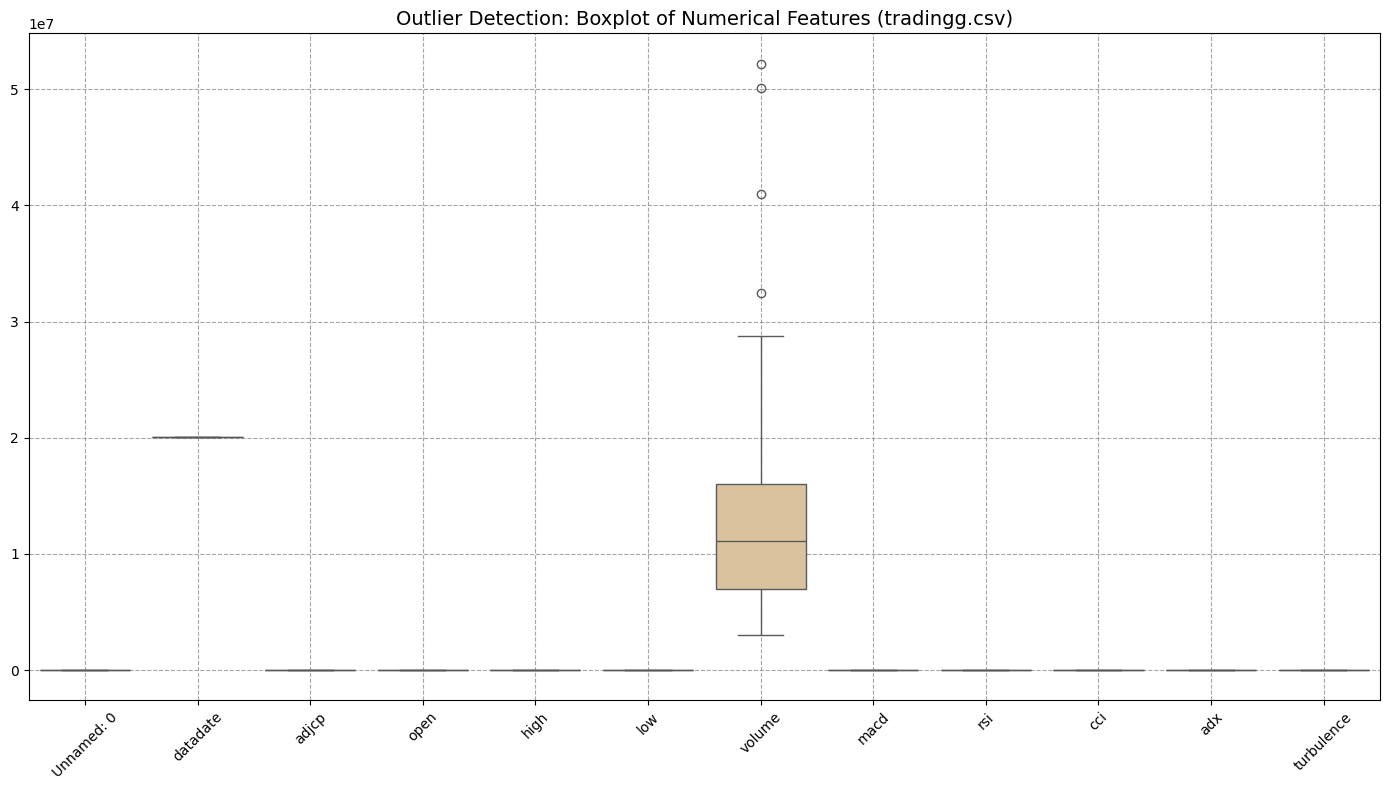

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Outlier Visualization using Boxplots
# Selecting numeric columns for outlier detection
numeric_cols = df_tradingg.select_dtypes(include=['number']).columns

plt.figure(figsize=(14, 8))
sns.boxplot(data=df_tradingg[numeric_cols], palette='Set2')
plt.title('Outlier Detection: Boxplot of Numerical Features (tradingg.csv)', fontsize=14)
plt.xticks(rotation=45)

# Implement the 'true grid'
plt.grid(True, which='both', linestyle='--', linewidth=0.8, color='gray', alpha=0.7)

plt.tight_layout()
plt.show()